# Feature Impact Visualizations (EDA) for Datasets 1, 2, and 3

## Analyzing the impact of each feature on customer churn across all three datasets.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

try:
    plt.style.use('seaborn-v0_8')
except:
    plt.style.use('seaborn')

sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/mosomo82/COMP_SCI_5530/refs/heads/main/Project_Customer_Churn/raw_data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

df = df.drop('customerID', axis=1)
df.replace(' ', np.nan, inplace=True)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

print(f"Dataset shape: {df.shape}")
print(f"Churn rate: {df['Churn'].mean():.2%}")

Dataset shape: (7010, 20)
Churn rate: 26.49%


## Dataset Definitions

- Dataset 1: All features (full dataset)
- Dataset 2: SeniorCitizen, Partner, Dependents, MultipleLines, InternetService, OnlineBackup, DeviceProtection, TechSupport, Contract, MonthlyCharges, TotalCharges
- Dataset 3: Dependents, InternetService, TechSupport, Contract, TotalCharges


In [ ]:
dataset1_features = [col for col in df.columns if col != 'Churn']
dataset2_features = ['SeniorCitizen', 'Partner', 'Dependents', 'MultipleLines',
                     'InternetService', 'OnlineBackup', 'DeviceProtection',
                     'TechSupport', 'Contract', 'MonthlyCharges', 'TotalCharges']
dataset3_features = ['Dependents', 'InternetService', 'TechSupport', 'Contract', 'TotalCharges']

dataset1 = df[dataset1_features + ['Churn']].copy()
dataset2 = df[dataset2_features + ['Churn']].copy()
dataset3 = df[dataset3_features + ['Churn']].copy()

print(f"Dataset 1 shape: {dataset1.shape}")
print(f"Dataset 2 shape: {dataset2.shape}")
print(f"Dataset 3 shape: {dataset3.shape}")

Dataset 1 shape: (7010, 20)
Dataset 2 shape: (7010, 12)
Dataset 3 shape: (7010, 6)


## Overall Churn Distribution


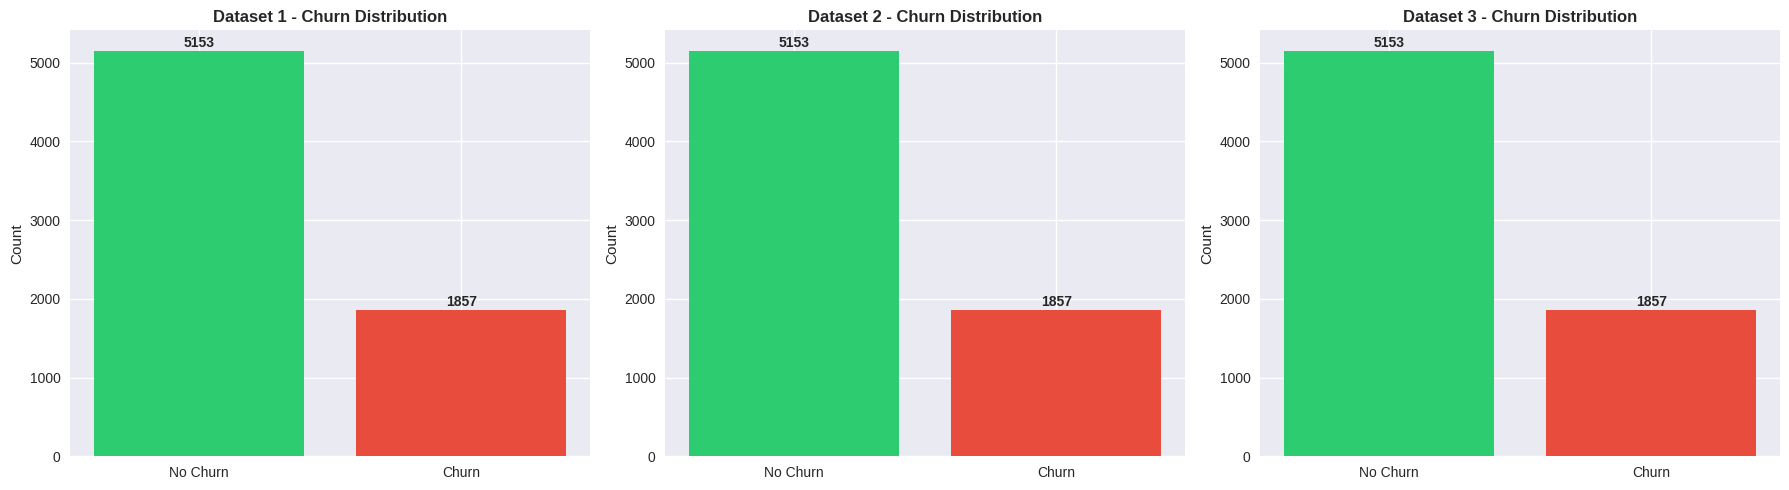

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (dataset, name) in enumerate([(dataset1, 'Dataset 1'), (dataset2, 'Dataset 2'), (dataset3, 'Dataset 3')]):
    churn_counts = dataset['Churn'].value_counts()
    axes[idx].bar(['No Churn', 'Churn'], churn_counts.values, color=['#2ecc71', '#e74c3c'])
    axes[idx].set_title(f'{name} - Churn Distribution', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Count')
    for i, v in enumerate(churn_counts.values):
        axes[idx].text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## Feature Impact Analysis


In [ ]:
def encode_feature_for_regression(feature_data):
    if feature_data.dtype == 'object':
        le = LabelEncoder()
        return le.fit_transform(feature_data.astype(str))
    return feature_data.values

def calculate_feature_impact(feature_name, feature_data, target):
    X = encode_feature_for_regression(feature_data).reshape(-1, 1)
    y = target.values

    model = LinearRegression()
    model.fit(X, y)

    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)
    coefficient = model.coef_[0]
    intercept = model.intercept_

    return {
        'feature': feature_name,
        'coefficient': coefficient,
        'intercept': intercept,
        'r2_score': r2,
        'model': model,
        'X': X,
        'y': y,
        'y_pred': y_pred
    }

def analyze_dataset(dataset, dataset_name):
    features = [col for col in dataset.columns if col != 'Churn']
    feature_impacts = {}

    for feature in features:
        feature_impacts[feature] = calculate_feature_impact(
            feature,
            dataset[feature],
            dataset['Churn']
        )

    impact_df = pd.DataFrame({
        'Feature': [f['feature'] for f in feature_impacts.values()],
        'Coefficient': [f['coefficient'] for f in feature_impacts.values()],
        'R2_Score': [f['r2_score'] for f in feature_impacts.values()]
    }).sort_values('R2_Score', ascending=False)

    return feature_impacts, impact_df

In [ ]:
impacts1, impact_df1 = analyze_dataset(dataset1, 'Dataset 1')
impacts2, impact_df2 = analyze_dataset(dataset2, 'Dataset 2')
impacts3, impact_df3 = analyze_dataset(dataset3, 'Dataset 3')

print("Dataset 1 - Feature Impact Summary (sorted by R2 Score):")
print(impact_df1.to_string(index=False))
print("\n" + "="*60)
print("Dataset 2 - Feature Impact Summary (sorted by R2 Score):")
print(impact_df2.to_string(index=False))
print("\n" + "="*60)
print("Dataset 3 - Feature Impact Summary (sorted by R2 Score):")
print(impact_df3.to_string(index=False))

Dataset 1 - Feature Impact Summary (sorted by R2 Score):
         Feature  Coefficient  R2_Score
        Contract    -0.209693  0.156791
          tenure    -0.006359  0.124848
  OnlineSecurity    -0.147770  0.083086
     TechSupport    -0.143971  0.079183
    TotalCharges    -0.000039  0.039347
  MonthlyCharges     0.002848  0.037639
    OnlineBackup    -0.097144  0.037628
PaperlessBilling     0.171142  0.036297
DeviceProtection    -0.088421  0.031159
      Dependents    -0.156437  0.026363
   SeniorCitizen     0.180827  0.022883
         Partner    -0.131278  0.022103
   PaymentMethod     0.044272  0.011456
 InternetService    -0.028262  0.002225
   MultipleLines     0.018692  0.001614
 StreamingMovies    -0.018328  0.001354
     StreamingTV    -0.017090  0.001177
    PhoneService     0.016509  0.000123
          gender    -0.007674  0.000076

Dataset 2 - Feature Impact Summary (sorted by R2 Score):
         Feature  Coefficient  R2_Score
        Contract    -0.209693  0.156791
     

## Dataset 1 Visualizations
### Top Features by Impact on Churn (Dataset 1)

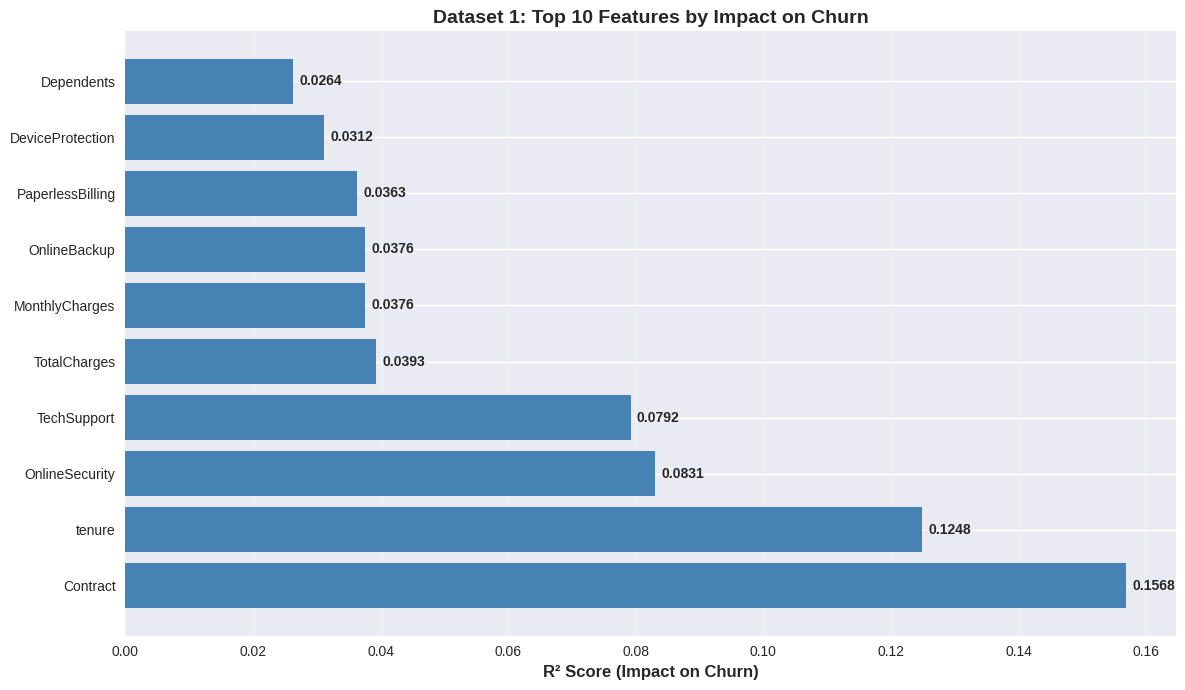

In [ ]:
top_features1 = impact_df1.head(10)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top_features1['Feature'], top_features1['R2_Score'], color='steelblue')
ax.set_xlabel('R² Score (Impact on Churn)', fontsize=12, fontweight='bold')
ax.set_title('Dataset 1: Top 10 Features by Impact on Churn', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

for i, (idx, row) in enumerate(top_features1.iterrows()):
    ax.text(row['R2_Score'] + 0.001, i, f'{row["R2_Score"]:.4f}',
            va='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Numeric Features Impact (Dataset 1)


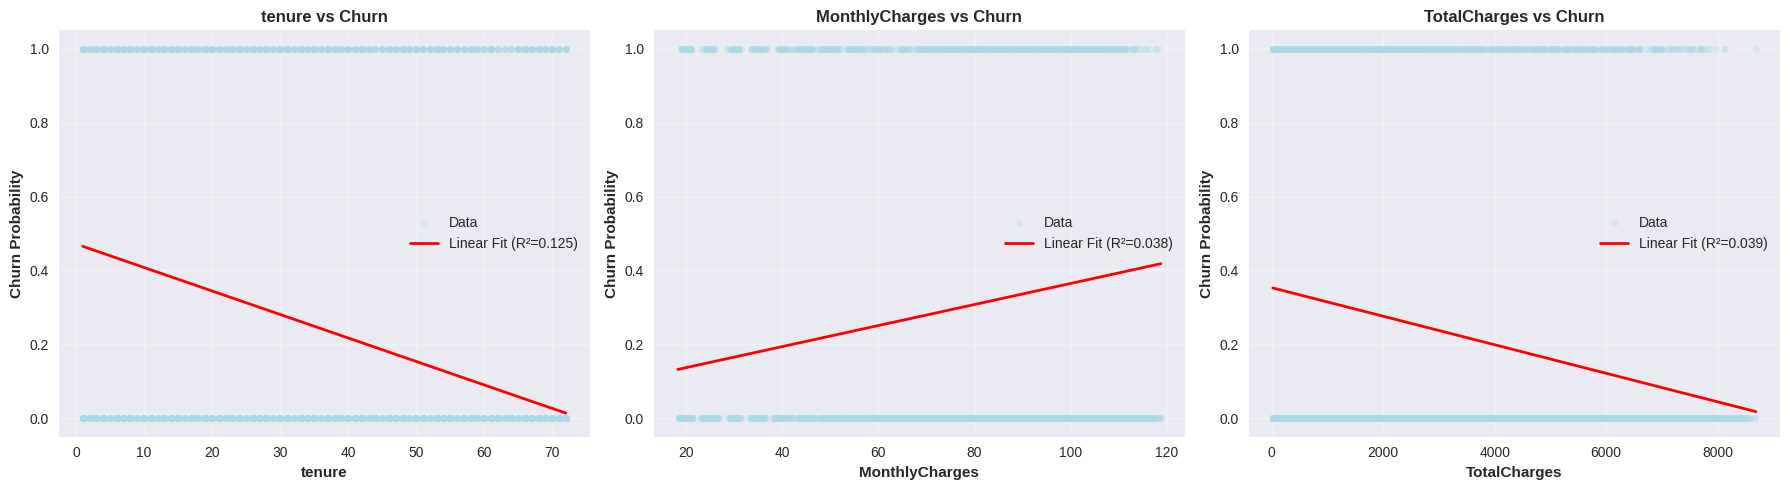

In [ ]:
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
numeric_features = [f for f in numeric_features if f in dataset1_features]

fig, axes = plt.subplots(1, len(numeric_features), figsize=(6*len(numeric_features), 5))

for idx, feature in enumerate(numeric_features):
    impact = impacts1[feature]
    X_plot = np.linspace(impact['X'].min(), impact['X'].max(), 100).reshape(-1, 1)
    y_plot = impact['model'].predict(X_plot)

    axes[idx].scatter(impact['X'], impact['y'], alpha=0.3, s=20, color='lightblue', label='Data')
    axes[idx].plot(X_plot, y_plot, 'r-', linewidth=2, label=f'Linear Fit (R²={impact["r2_score"]:.3f})')
    axes[idx].set_xlabel(feature, fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Churn Probability', fontsize=11, fontweight='bold')
    axes[idx].set_title(f'{feature} vs Churn', fontsize=12, fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

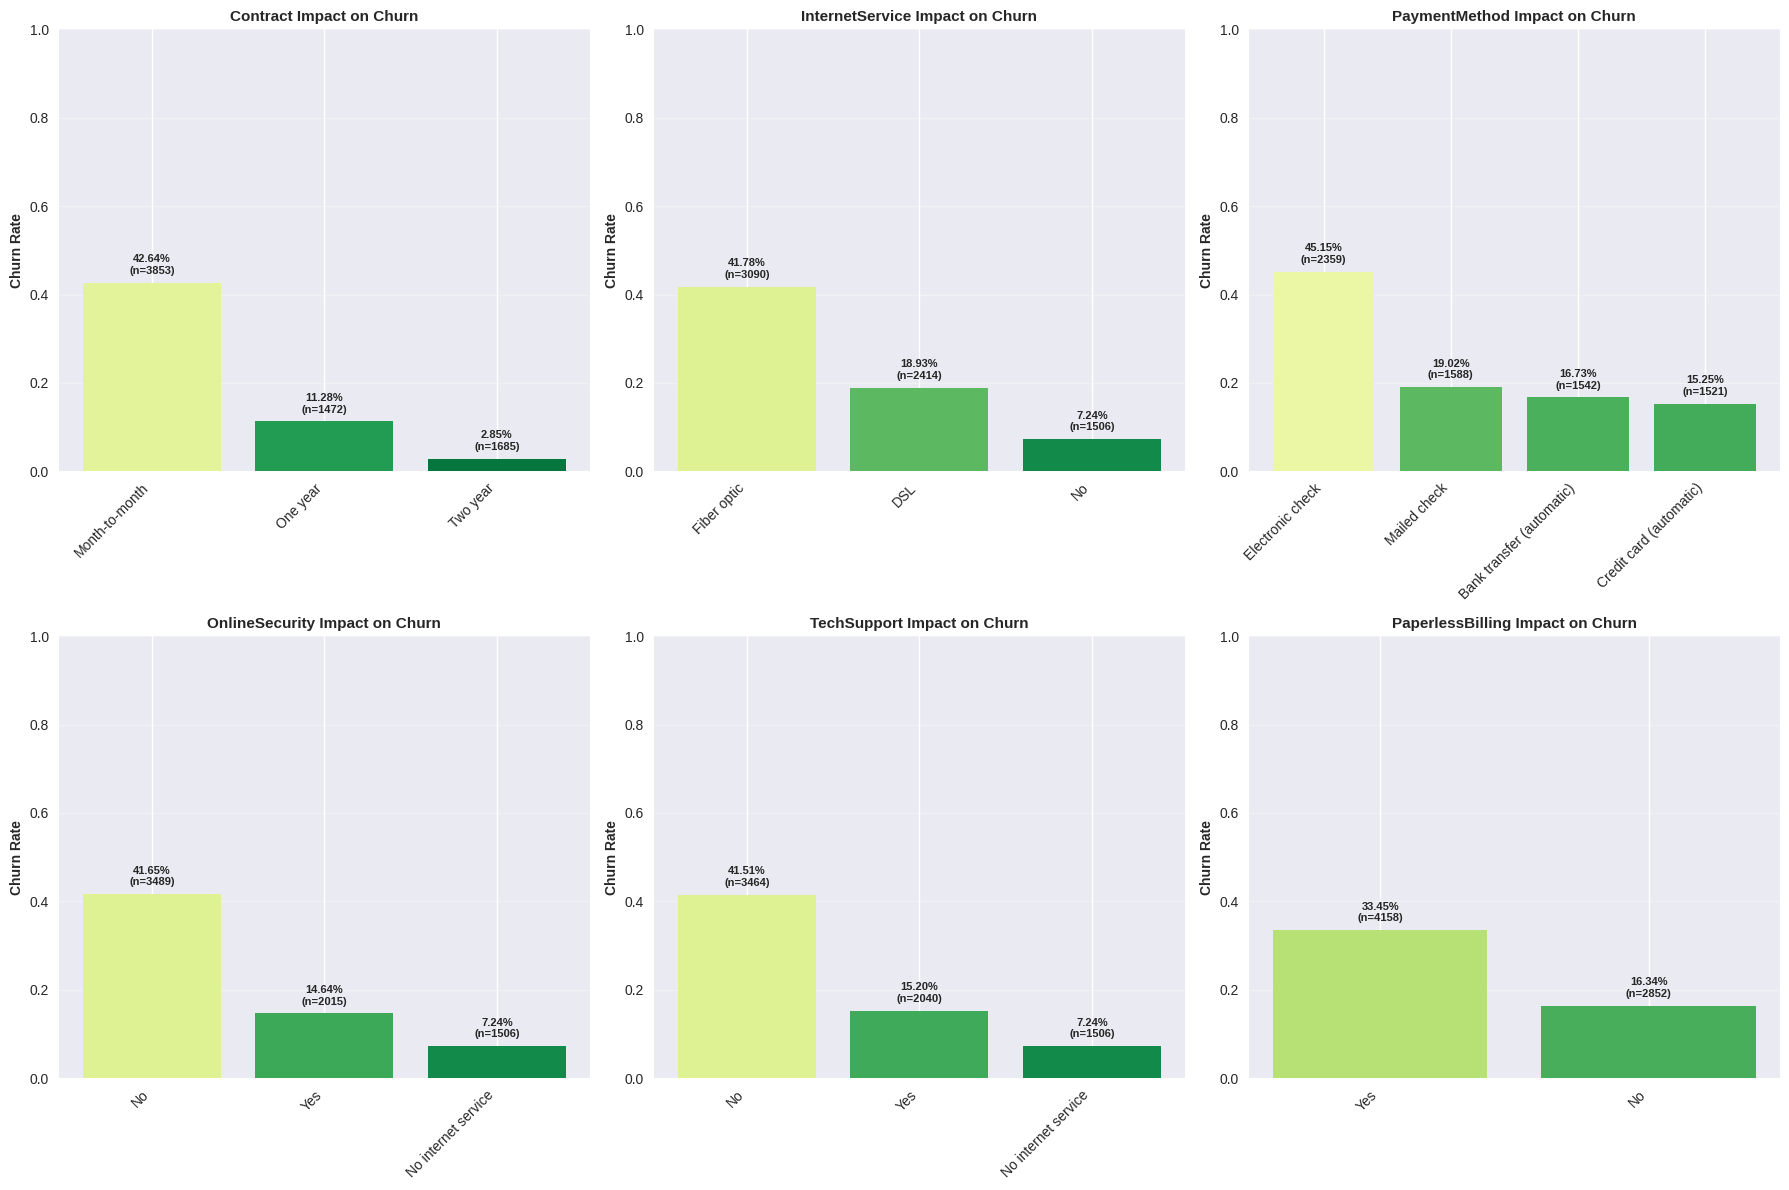

In [ ]:
top_categorical = ['Contract', 'InternetService', 'PaymentMethod', 'OnlineSecurity', 'TechSupport', 'PaperlessBilling']
top_categorical = [f for f in top_categorical if f in dataset1_features]

n_cols = 3
n_rows = (len(top_categorical) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6*n_rows))
axes = axes.flatten() if n_rows > 1 else [axes] if n_rows == 1 else axes

for idx, feature in enumerate(top_categorical):
    churn_by_feature = dataset1.groupby(feature)['Churn'].agg(['mean', 'count']).reset_index()
    churn_by_feature = churn_by_feature.sort_values('mean', ascending=False)

    bars = axes[idx].bar(range(len(churn_by_feature)), churn_by_feature['mean'],
                        color=plt.cm.RdYlGn_r(churn_by_feature['mean']))
    axes[idx].set_xticks(range(len(churn_by_feature)))
    axes[idx].set_xticklabels(churn_by_feature[feature], rotation=45, ha='right')
    axes[idx].set_ylabel('Churn Rate', fontsize=10, fontweight='bold')
    axes[idx].set_title(f'{feature} Impact on Churn', fontsize=11, fontweight='bold')
    axes[idx].set_ylim([0, 1])
    axes[idx].grid(axis='y', alpha=0.3)

    for i, (mean_val, count) in enumerate(zip(churn_by_feature['mean'], churn_by_feature['count'])):
        axes[idx].text(i, mean_val + 0.02, f'{mean_val:.2%}\n(n={count})',
                      ha='center', fontsize=8, fontweight='bold')

for idx in range(len(top_categorical), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## Dataset 2 Visualizations
### Top Features by Impact on Churn (Dataset 2)

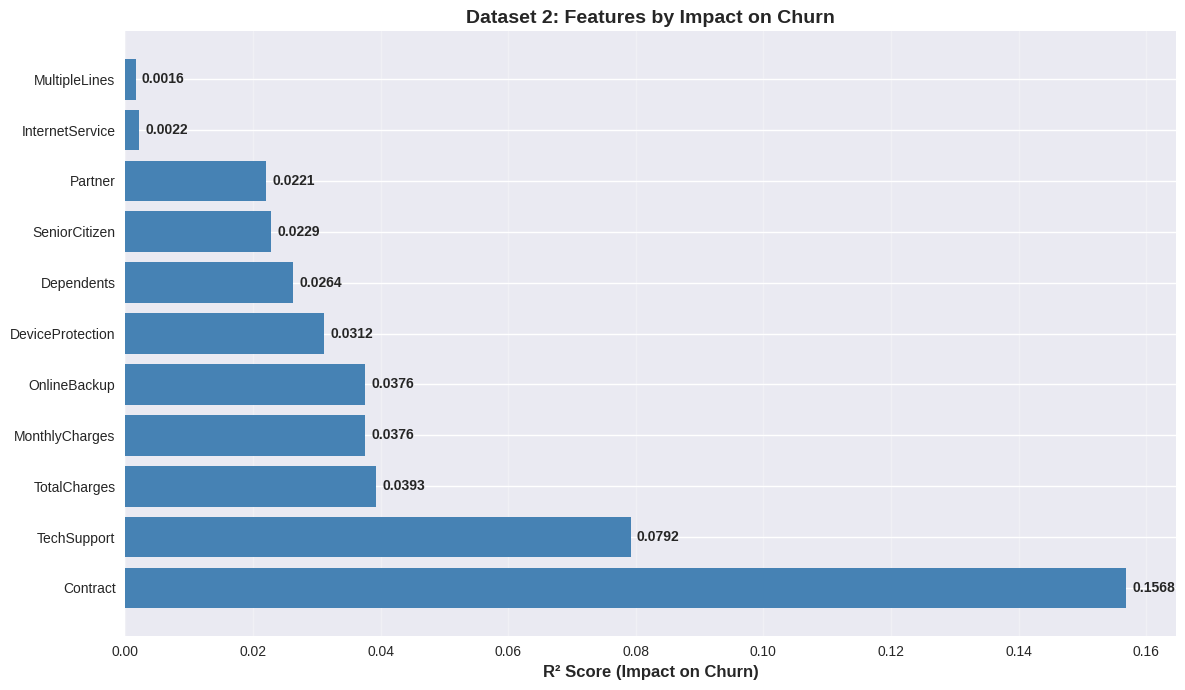

In [ ]:
top_features2 = impact_df2.head(len(dataset2_features))

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top_features2['Feature'], top_features2['R2_Score'], color='steelblue')
ax.set_xlabel('R² Score (Impact on Churn)', fontsize=12, fontweight='bold')
ax.set_title('Dataset 2: Features by Impact on Churn', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

for i, (idx, row) in enumerate(top_features2.iterrows()):
    ax.text(row['R2_Score'] + 0.001, i, f'{row["R2_Score"]:.4f}',
            va='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Feature Impact Visualizations (Dataset 2)


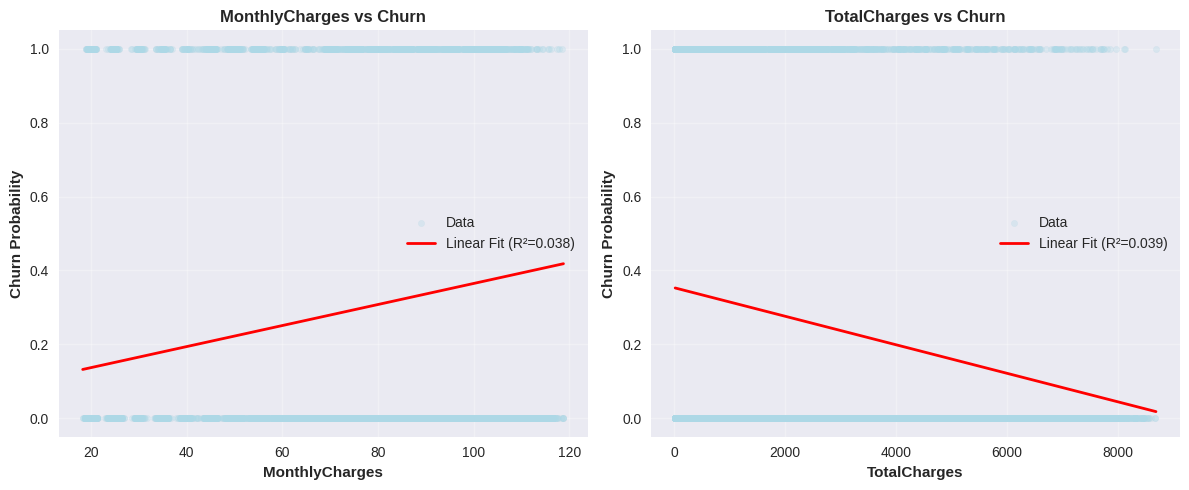

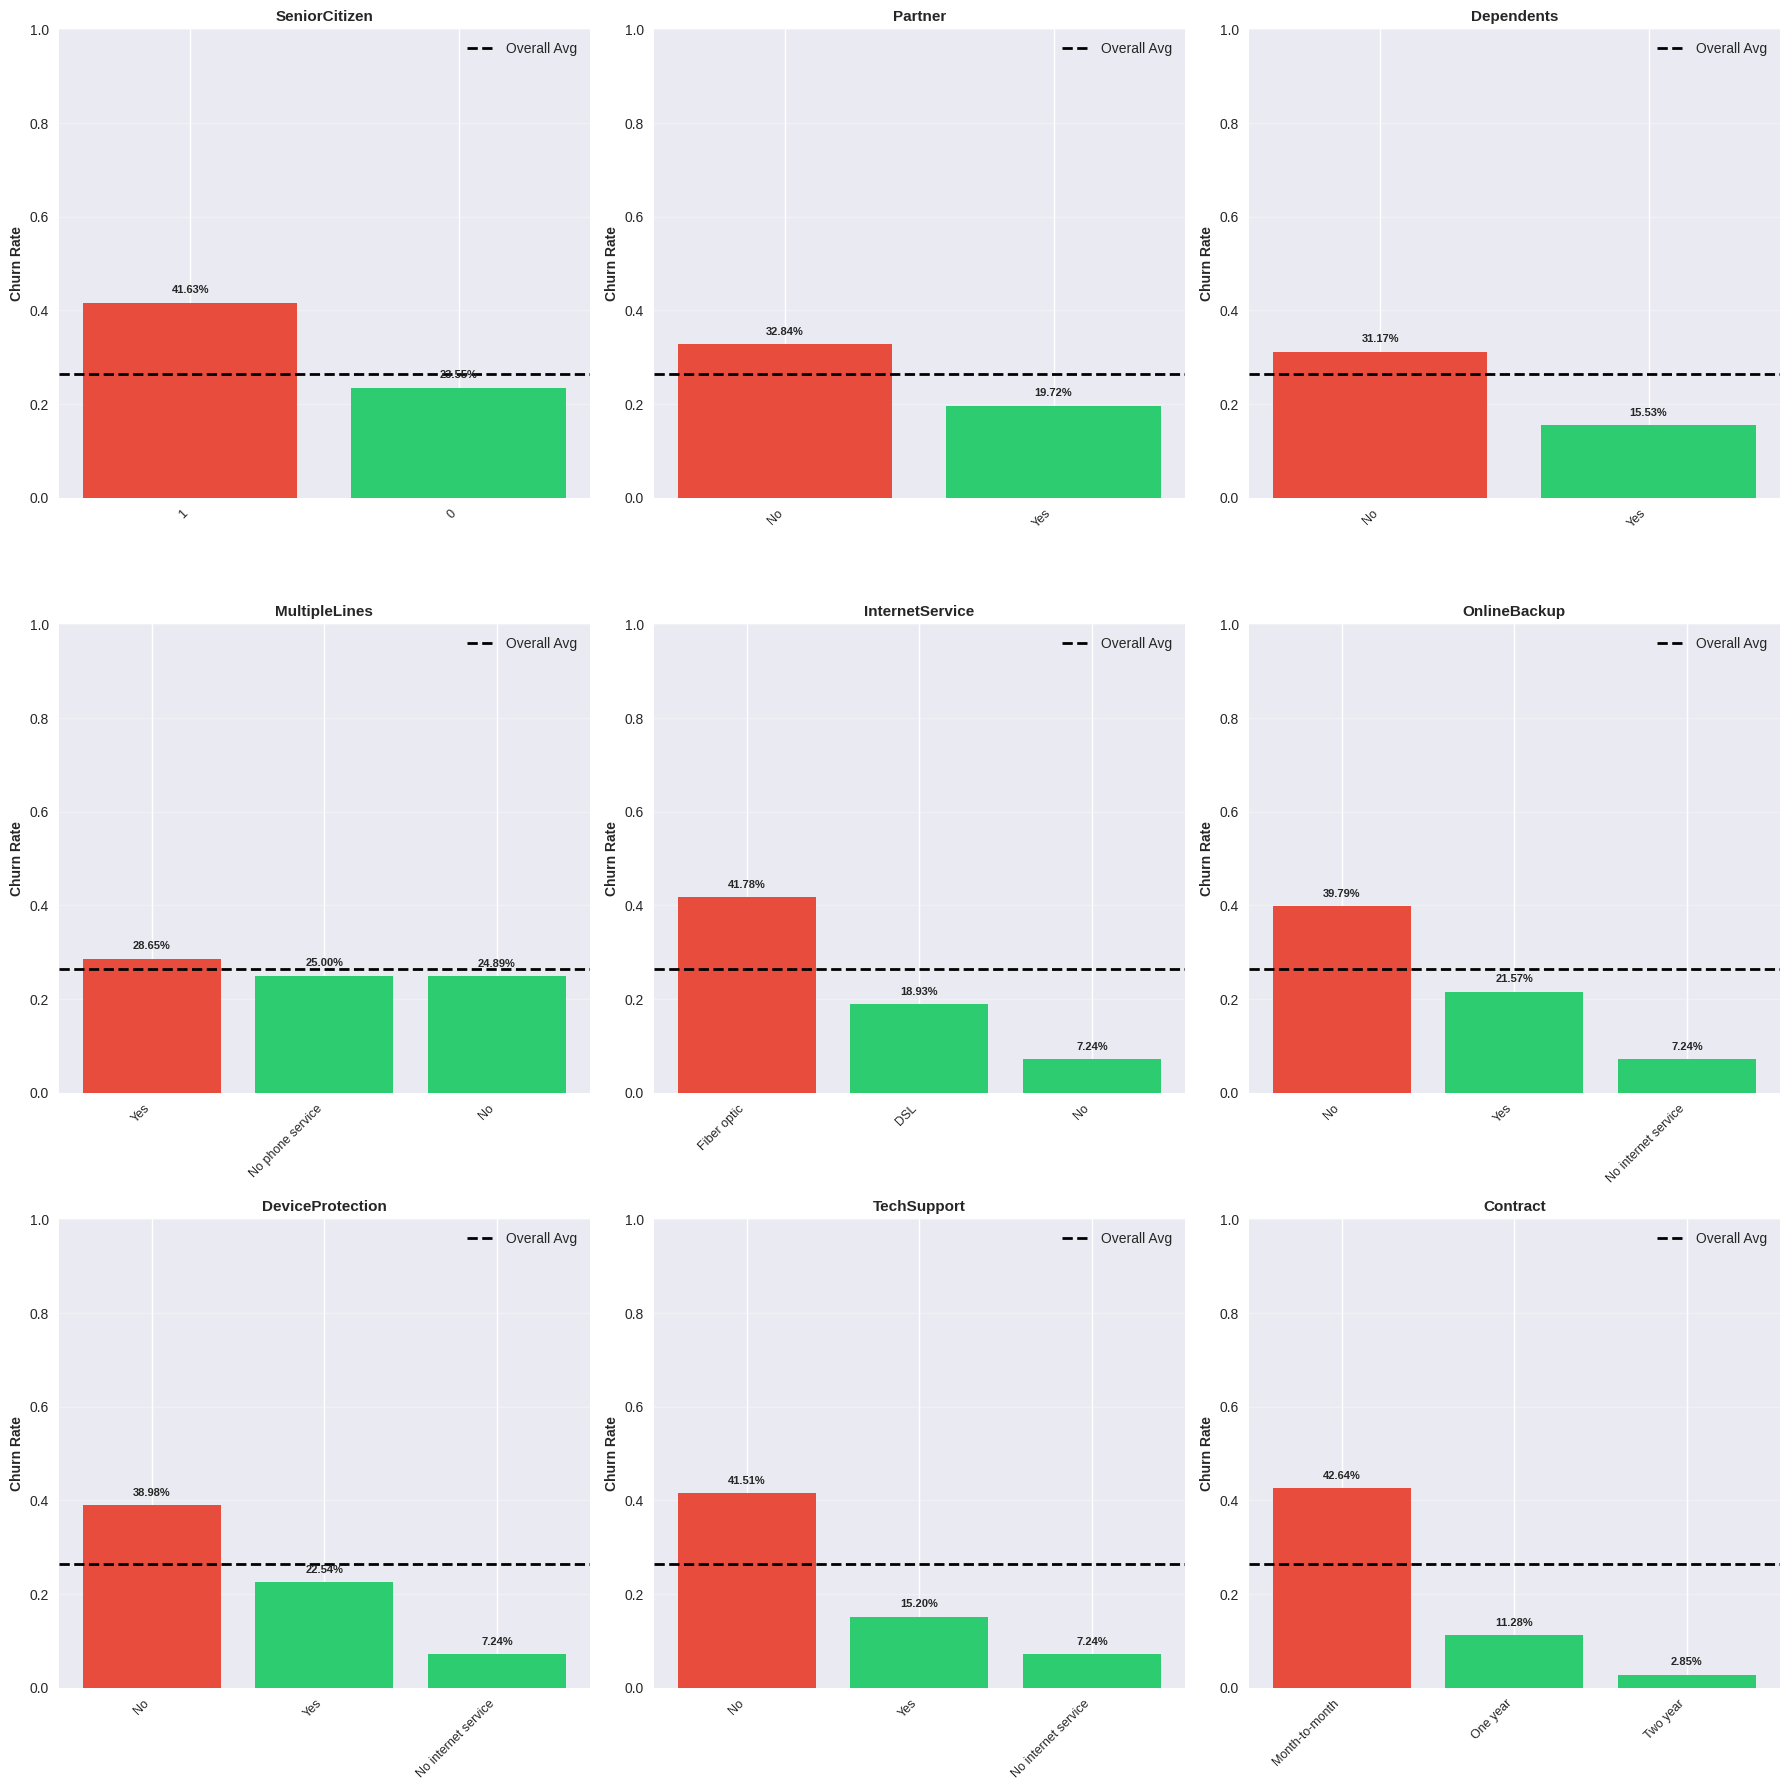

In [ ]:
numeric_ds2 = ['MonthlyCharges', 'TotalCharges']
numeric_ds2 = [f for f in numeric_ds2 if f in dataset2_features]
categorical_ds2 = [f for f in dataset2_features if f not in numeric_ds2]

if numeric_ds2:
    fig, axes = plt.subplots(1, len(numeric_ds2), figsize=(6*len(numeric_ds2), 5))
    if len(numeric_ds2) == 1:
        axes = [axes]

    for idx, feature in enumerate(numeric_ds2):
        impact = impacts2[feature]
        X_plot = np.linspace(impact['X'].min(), impact['X'].max(), 100).reshape(-1, 1)
        y_plot = impact['model'].predict(X_plot)

        axes[idx].scatter(impact['X'], impact['y'], alpha=0.3, s=20, color='lightblue', label='Data')
        axes[idx].plot(X_plot, y_plot, 'r-', linewidth=2, label=f'Linear Fit (R²={impact["r2_score"]:.3f})')
        axes[idx].set_xlabel(feature, fontsize=11, fontweight='bold')
        axes[idx].set_ylabel('Churn Probability', fontsize=11, fontweight='bold')
        axes[idx].set_title(f'{feature} vs Churn', fontsize=12, fontweight='bold')
        axes[idx].legend()
        axes[idx].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

n_cols = 3
n_rows = (len(categorical_ds2) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6*n_rows))
axes = axes.flatten() if n_rows > 1 else [axes] if n_rows == 1 else axes

for idx, feature in enumerate(categorical_ds2):
    churn_by_feature = dataset2.groupby(feature)['Churn'].agg(['mean', 'count']).reset_index()
    churn_by_feature = churn_by_feature.sort_values('mean', ascending=False)

    colors = ['#e74c3c' if x > dataset2['Churn'].mean() else '#2ecc71'
              for x in churn_by_feature['mean']]

    bars = axes[idx].bar(range(len(churn_by_feature)), churn_by_feature['mean'], color=colors)
    axes[idx].axhline(y=dataset2['Churn'].mean(), color='black', linestyle='--',
                     linewidth=2, label='Overall Avg')
    axes[idx].set_xticks(range(len(churn_by_feature)))
    axes[idx].set_xticklabels(churn_by_feature[feature], rotation=45, ha='right', fontsize=9)
    axes[idx].set_ylabel('Churn Rate', fontsize=10, fontweight='bold')
    axes[idx].set_title(f'{feature}', fontsize=11, fontweight='bold')
    axes[idx].set_ylim([0, 1])
    axes[idx].grid(axis='y', alpha=0.3)
    axes[idx].legend()

    for i, mean_val in enumerate(churn_by_feature['mean']):
        axes[idx].text(i, mean_val + 0.02, f'{mean_val:.2%}',
                      ha='center', fontsize=8, fontweight='bold')

for idx in range(len(categorical_ds2), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## Dataset 3 Visualizations
### Top Features by Impact on Churn (Dataset 3)

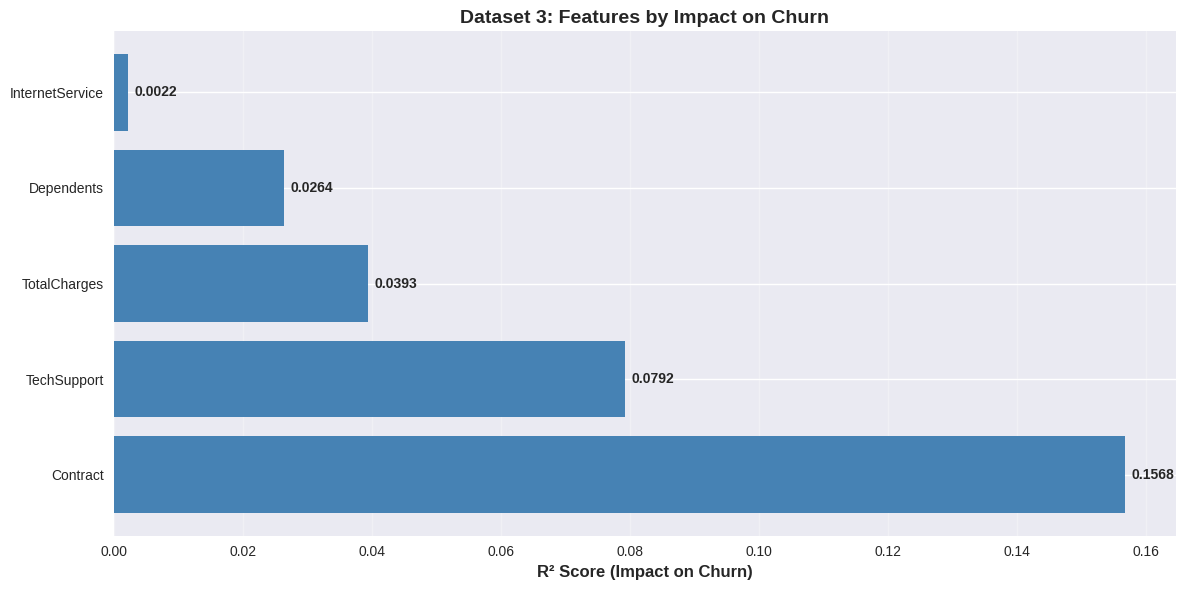

In [ ]:
top_features3 = impact_df3.head(len(dataset3_features))

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_features3['Feature'], top_features3['R2_Score'], color='steelblue')
ax.set_xlabel('R² Score (Impact on Churn)', fontsize=12, fontweight='bold')
ax.set_title('Dataset 3: Features by Impact on Churn', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

for i, (idx, row) in enumerate(top_features3.iterrows()):
    ax.text(row['R2_Score'] + 0.001, i, f'{row["R2_Score"]:.4f}',
            va='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Feature Impact Visualizations (Dataset 3)


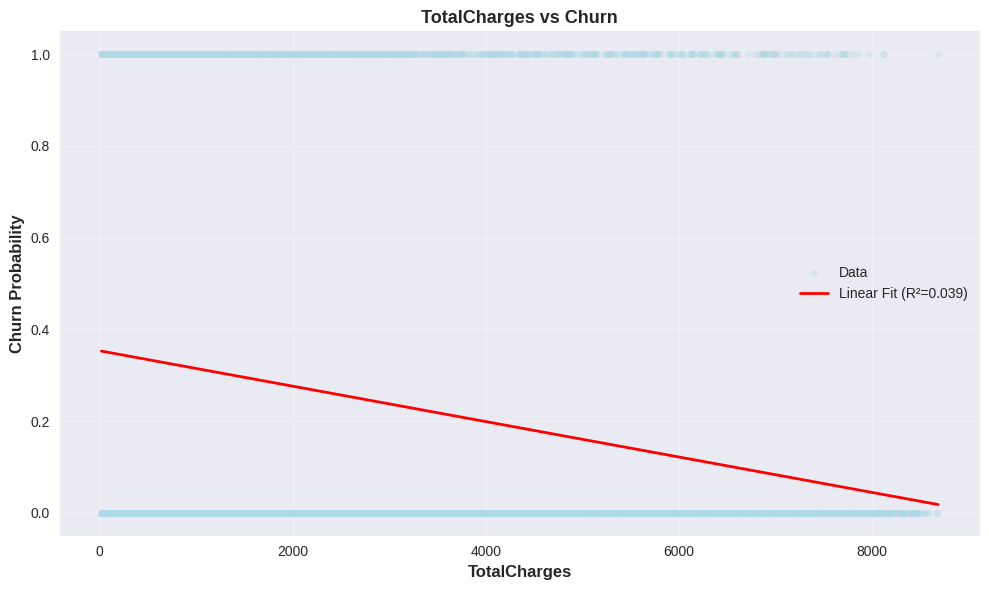

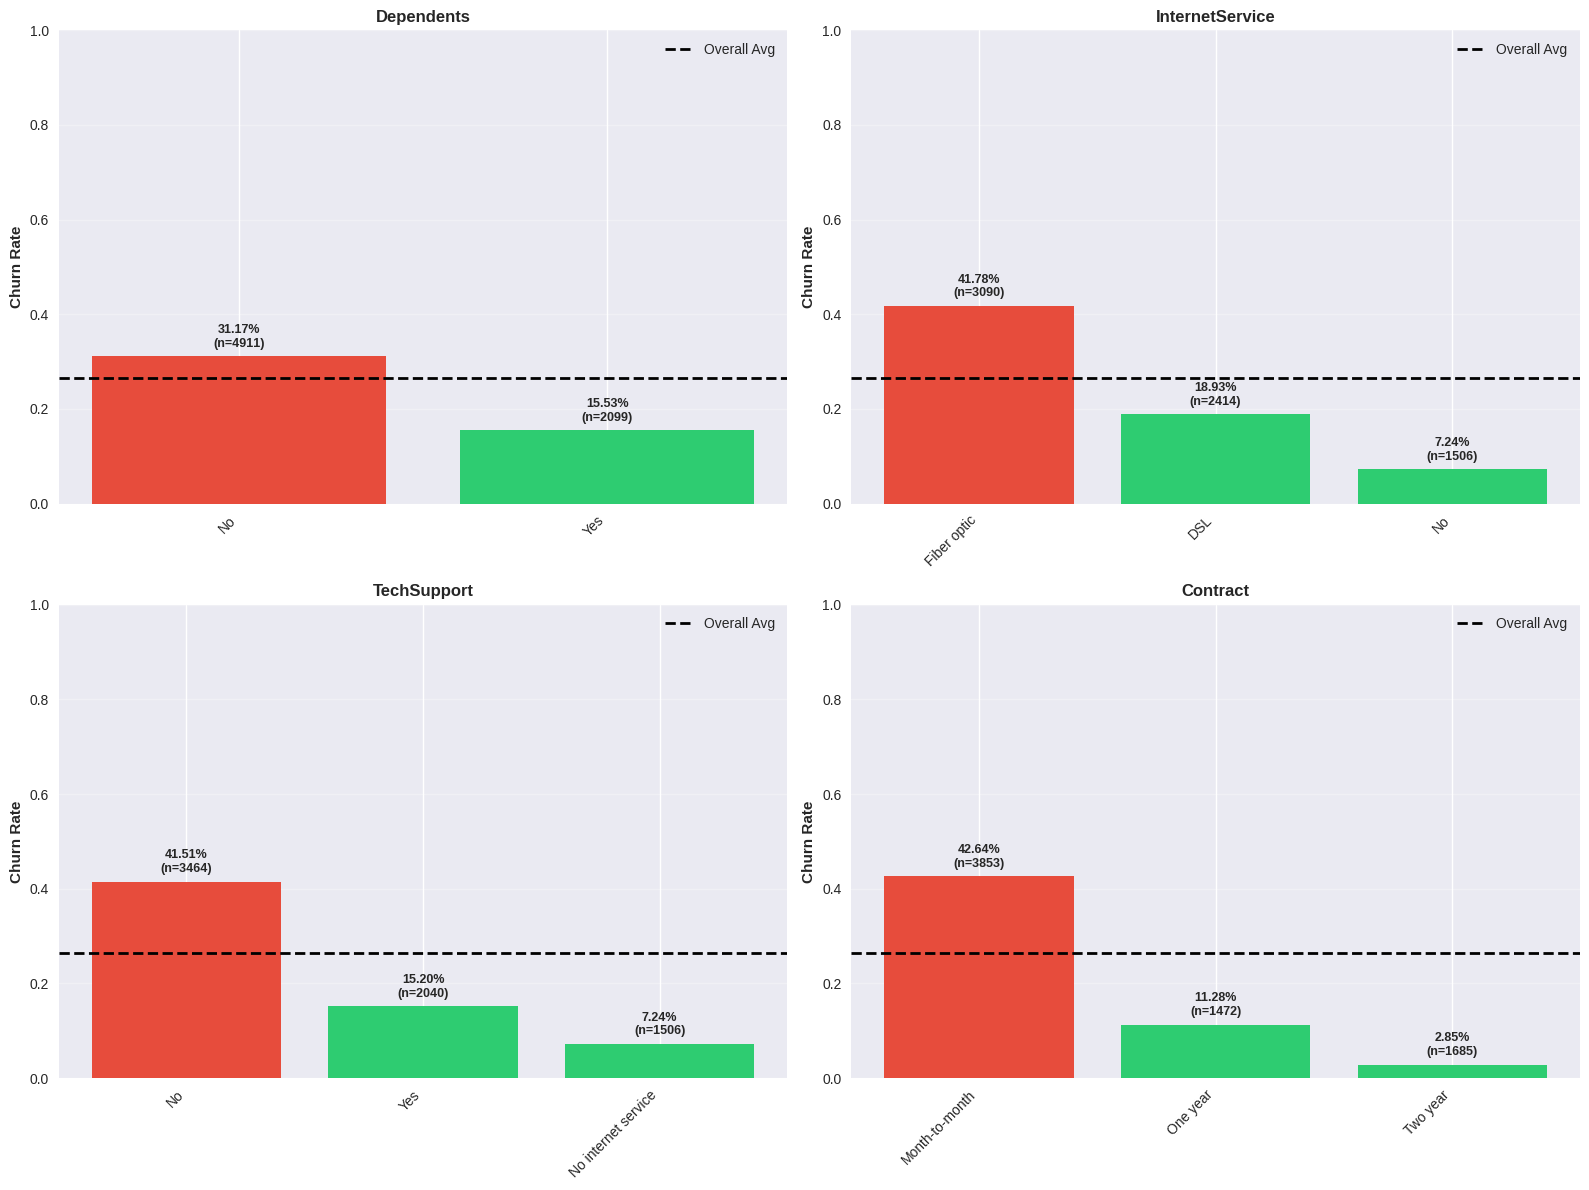

In [ ]:
numeric_ds3 = ['TotalCharges']
numeric_ds3 = [f for f in numeric_ds3 if f in dataset3_features]
categorical_ds3 = [f for f in dataset3_features if f not in numeric_ds3]

if numeric_ds3:
    fig, ax = plt.subplots(figsize=(10, 6))
    feature = numeric_ds3[0]
    impact = impacts3[feature]
    X_plot = np.linspace(impact['X'].min(), impact['X'].max(), 100).reshape(-1, 1)
    y_plot = impact['model'].predict(X_plot)

    ax.scatter(impact['X'], impact['y'], alpha=0.3, s=20, color='lightblue', label='Data')
    ax.plot(X_plot, y_plot, 'r-', linewidth=2, label=f'Linear Fit (R²={impact["r2_score"]:.3f})')
    ax.set_xlabel(feature, fontsize=12, fontweight='bold')
    ax.set_ylabel('Churn Probability', fontsize=12, fontweight='bold')
    ax.set_title(f'{feature} vs Churn', fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

n_cols = 2
n_rows = (len(categorical_ds3) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 6*n_rows))
axes = axes.flatten() if n_rows > 1 else [axes] if n_rows == 1 else axes

for idx, feature in enumerate(categorical_ds3):
    churn_by_feature = dataset3.groupby(feature)['Churn'].agg(['mean', 'count']).reset_index()
    churn_by_feature = churn_by_feature.sort_values('mean', ascending=False)

    colors = ['#e74c3c' if x > dataset3['Churn'].mean() else '#2ecc71'
              for x in churn_by_feature['mean']]

    bars = axes[idx].bar(range(len(churn_by_feature)), churn_by_feature['mean'], color=colors)
    axes[idx].axhline(y=dataset3['Churn'].mean(), color='black', linestyle='--',
                     linewidth=2, label='Overall Avg')
    axes[idx].set_xticks(range(len(churn_by_feature)))
    axes[idx].set_xticklabels(churn_by_feature[feature], rotation=45, ha='right', fontsize=10)
    axes[idx].set_ylabel('Churn Rate', fontsize=11, fontweight='bold')
    axes[idx].set_title(f'{feature}', fontsize=12, fontweight='bold')
    axes[idx].set_ylim([0, 1])
    axes[idx].grid(axis='y', alpha=0.3)
    axes[idx].legend()

    for i, (mean_val, count) in enumerate(zip(churn_by_feature['mean'], churn_by_feature['count'])):
        axes[idx].text(i, mean_val + 0.02, f'{mean_val:.2%}\n(n={count})',
                      ha='center', fontsize=9, fontweight='bold')

for idx in range(len(categorical_ds3), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## Summary Statistics


In [ ]:
print("FEATURE IMPACT SUMMARY FOR ALL DATASETS")

for idx, (dataset, name, impact_df) in enumerate([
    (dataset1, 'Dataset 1', impact_df1),
    (dataset2, 'Dataset 2', impact_df2),
    (dataset3, 'Dataset 3', impact_df3)
], 1):
    print(f"\n{name}:")
    print(f"  Total Records: {len(dataset)}")
    print(f"  Overall Churn Rate: {dataset['Churn'].mean():.2%}")
    print(f"  Number of Features: {len(dataset.columns) - 1}")
    print(f"  Top 3 Features by R² Score:")
    for i, row in impact_df.head(3).iterrows():
        print(f"    - {row['Feature']}: R² = {row['R2_Score']:.4f}")

FEATURE IMPACT SUMMARY - ALL DATASETS

Dataset 1:
  Total Records: 7010
  Overall Churn Rate: 26.49%
  Number of Features: 19
  Top 3 Features by R² Score:
    - Contract: R² = 0.1568
    - tenure: R² = 0.1248
    - OnlineSecurity: R² = 0.0831

Dataset 2:
  Total Records: 7010
  Overall Churn Rate: 26.49%
  Number of Features: 11
  Top 3 Features by R² Score:
    - Contract: R² = 0.1568
    - TechSupport: R² = 0.0792
    - TotalCharges: R² = 0.0393

Dataset 3:
  Total Records: 7010
  Overall Churn Rate: 26.49%
  Number of Features: 5
  Top 3 Features by R² Score:
    - Contract: R² = 0.1568
    - TechSupport: R² = 0.0792
    - TotalCharges: R² = 0.0393

